In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.metrics import accuracy_score

X, y = make_moons(n_samples=1000, noise=0.22, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [2]:
base_estimators = [
    ("lr", LogisticRegression(random_state=42)),
    ("svc", SVC(probability=True, random_state=42)),
    ("tree", DecisionTreeClassifier(max_depth=3, random_state=42))
]
meta_clf = LogisticRegression(random_state=42)
stack_clf = StackingClassifier(
    estimators=base_estimators,
    final_estimator=meta_clf,     # 次级元学习器
    cv=5,                         # 5折交叉验证生成元特征（核心！防止泄露）
    stack_method="predict_proba", # 使用概率作为元特征；可选"predict"类别
    passthrough=False             # False：只用基模型输出；True：附加原始特征
)

lr = LogisticRegression(random_state=42)
svc = SVC(probability=True, random_state=42)
tree = DecisionTreeClassifier(max_depth=3, random_state=42)

lr.fit(X_train, y_train)
svc.fit(X_train, y_train)
tree.fit(X_train, y_train)
stack_clf.fit(X_train, y_train)

,estimators,"[('lr', ...), ('svc', ...), ...]"
,final_estimator,LogisticRegre...ndom_state=42)
,cv,5
,stack_method,'predict_proba'
,n_jobs,None
,passthrough,False
,verbose,0
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [3]:
def print_acc(model, name):
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    print(f"{name:16s} | Test Acc: {acc:.4f}")

print_acc(lr, "LogisticRegression")
print_acc(svc, "SVC")
print_acc(tree, "DecisionTree")
print_acc(stack_clf, "Stacking")

LogisticRegression | Test Acc: 0.8733
SVC              | Test Acc: 0.9633
DecisionTree     | Test Acc: 0.9067
Stacking         | Test Acc: 0.9700


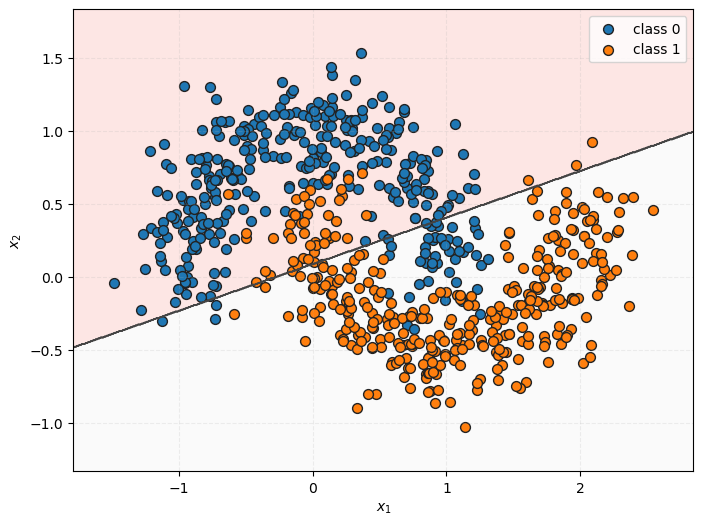

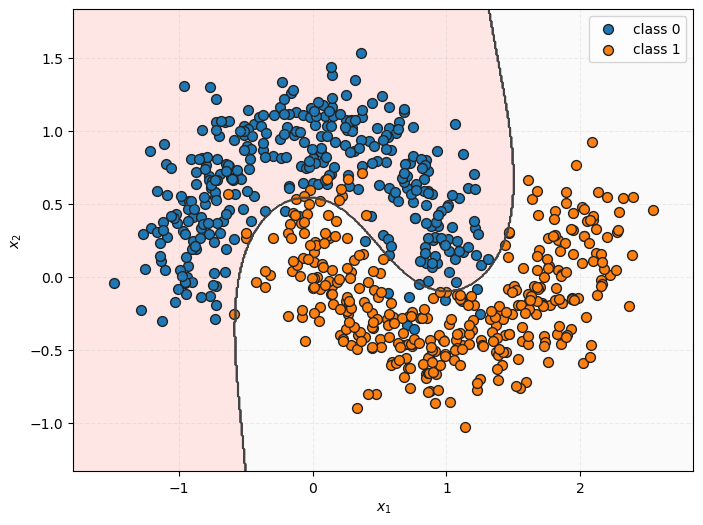

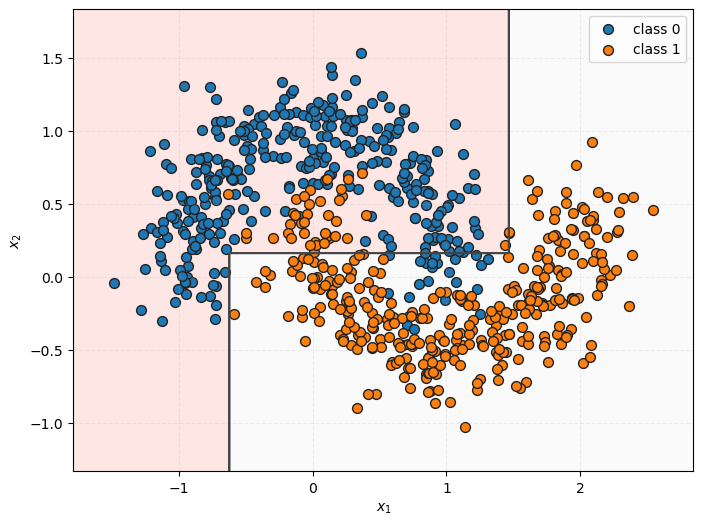

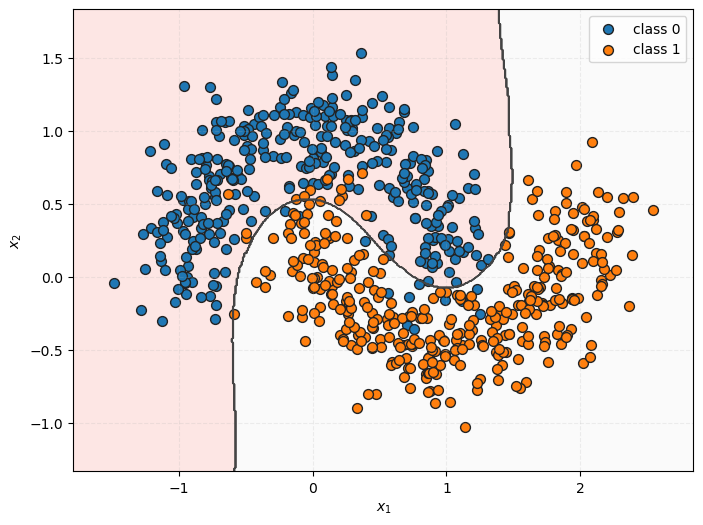

In [4]:
def plot_decision_boundary(clf, X, y, title=None):
    plt.figure(figsize=(8,6))
    x0_min, x0_max = X[:,0].min() - 0.3, X[:,0].max() + 0.3
    x1_min, x1_max = X[:,1].min() - 0.3, X[:,1].max() + 0.3
    xx0, xx1 = np.meshgrid(np.linspace(x0_min, x0_max, 500),
                           np.linspace(x1_min, x1_max, 500))
    grid = np.c_[xx0.ravel(), xx1.ravel()]
    pred = clf.predict(grid).reshape(xx0.shape)

    plt.contourf(xx0, xx1, pred, alpha=0.32, cmap="Pastel1")
    plt.contour(xx0, xx1, pred, colors="#444444", linewidths=0.75)

    # 画出样本
    for label in np.unique(y):
        mask = (y == label)
        plt.scatter(X[mask,0], X[mask,1], s=50, edgecolors="#222222", label=f"class {label}")
    plt.xlabel("$x_1$")
    plt.ylabel("$x_2$")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.2, linestyle="--")
    plt.show()

# 依次画出单个模型 + 投票集成
plot_decision_boundary(lr, X_train, y_train)
plot_decision_boundary(svc, X_train, y_train)
plot_decision_boundary(tree, X_train, y_train)
plot_decision_boundary(stack_clf, X_train, y_train)